# 2 · Preprocessing & feature tour

Each `nextaire_tools` preprocessing step, shown on the same synthetic station so you can
see exactly what it changes. All steps are scikit-learn transformers and compose
inside a `Pipeline`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "reproductions"))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from _synthetic import make_graz_hourly

df = make_graz_hourly(n_days=120, seed=1)
df = df[["no", "no2", "o3", "pm10", "temp", "rh", "wind_speed", "wind_dir", "u10", "v10", "blh"]]
df.head(3)

,no,no2,o3,pm10,temp,rh,wind_speed,wind_dir,u10,v10,blh
timestamp,,,,,,,,,,,
2016-01-01 00:00:00,0.000000,5.772012,29.040666,435.508657,16.344369,86.053084,2.764556,236.081200,2.294109,1.542670,445.791088
2016-01-01 01:00:00,4.690601,12.279994,30.590504,38.372479,17.500882,78.779749,5.159873,201.234652,1.868846,4.809543,397.380370
2016-01-01 02:00:00,0.000000,12.905342,32.582993,34.739705,17.117922,76.319512,3.251897,173.018939,-0.395240,3.227789,446.075996


## Missing values

`MissingValueHandler` supports dropping, statistical / directional filling,
time-aware interpolation, and multivariate **iterative** imputation.

In [2]:
from nextaire_tools.preprocessing import MissingValueHandler

print("NaNs before:", int(df.isna().sum().sum()))

interp = MissingValueHandler(strategy="interpolate", limit=3).fit_transform(df)
print("after interpolate:", int(interp.isna().sum().sum()))

# Multivariate imputation (models each column from the others).
iterative = MissingValueHandler(strategy="iterative", random_state=0).fit_transform(df)
print("after iterative :", int(iterative.isna().sum().sum()))

NaNs before: 44
after interpolate: 0
after iterative : 0


## Outliers

`OutlierHandler` offers IQR / z-score / modified z-score / quantile bounds, a
multivariate Isolation Forest, and **`rolling_sigma`** — time-local winsorisation
that removes short-lived spikes (e.g. New-Year fireworks) without deleting real
pollution events.

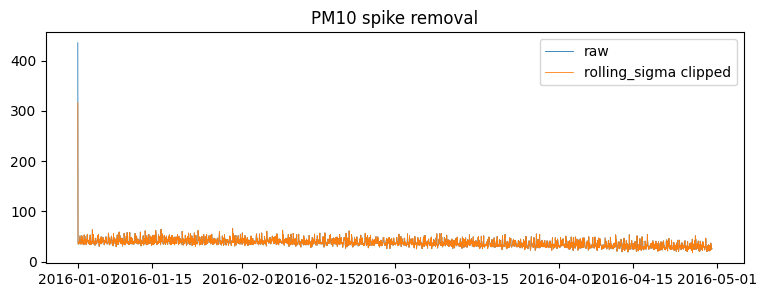

In [3]:
from nextaire_tools.preprocessing import OutlierHandler

win = OutlierHandler(
    columns=["pm10"], method="rolling_sigma", strategy="clip", window=72, sigma=4.0
).fit_transform(df)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(df.index, df["pm10"], lw=0.6, label="raw")
ax.plot(win.index, win["pm10"], lw=0.6, label="rolling_sigma clipped")
ax.set_title("PM10 spike removal"); ax.legend()
plt.show()

## Temporal features

Calendar fields plus sine/cosine encodings so hour 23 sits next to hour 0.

In [4]:
from nextaire_tools.preprocessing import TemporalFeatures

feat = TemporalFeatures(
    add=("hour", "dayofweek", "month"),
    cyclical=("hour", "dayofweek", "dayofyear"),
).fit_transform(df)
[c for c in feat.columns if c not in df.columns]

['hour',
 'dayofweek',
 'month',
 'hour_sin',
 'hour_cos',
 'dayofweek_sin',
 'dayofweek_cos',
 'dayofyear_sin',
 'dayofyear_cos']

## Wind decomposition

`WindDecomposer` turns wind direction into stable x/y components (no 0°/360°
discontinuity) and derives speed from u/v components.

In [5]:
from nextaire_tools.preprocessing import WindDecomposer

wind = WindDecomposer(direction_col="wind_dir", speed_from_uv=("u10", "v10")).fit_transform(df)
wind[["wind_dir", "wind_dir_x", "wind_dir_y", "wind_speed"]].head(3)

,wind_dir,wind_dir_x,wind_dir_y,wind_speed,wind_speed
timestamp,,,,,
2016-01-01 00:00:00,236.081200,-0.558017,-0.829829,2.764556,2.764556
2016-01-01 01:00:00,201.234652,-0.932105,-0.362188,5.159873,5.159873
2016-01-01 02:00:00,173.018939,-0.992586,0.121541,3.251897,3.251897


## Lag features

Causal lags and rolling aggregates, e.g. the median of the last 12 hours.

In [6]:
from nextaire_tools.preprocessing import LagFeatures

lagged = LagFeatures(columns=["no", "pm10"], lags=[1], windows=[12], agg="median").fit_transform(df)
[c for c in lagged.columns if c not in df.columns]

['no_lag1', 'no_roll12_median', 'pm10_lag1', 'pm10_roll12_median']

## Correlation filter

Drop collinear features above an absolute-correlation threshold, protecting the target.

In [7]:
from nextaire_tools.preprocessing import CorrelationFilter

cf = CorrelationFilter(threshold=0.9, protect=["no2"]).fit(df)
print("dropped:", cf.dropped_columns_)
print("kept   :", cf.kept_columns_)

dropped: []
kept   : ['no', 'no2', 'o3', 'pm10', 'temp', 'rh', 'wind_speed', 'wind_dir', 'u10', 'v10', 'blh']


## Compose everything

The same steps chained into one reproducible `Pipeline`.

In [8]:
from nextaire_tools import Pipeline
from nextaire_tools.preprocessing import Scaler

pipe = Pipeline([
    OutlierHandler(columns=["no", "no2", "o3", "pm10"], method="rolling_sigma", window=72, sigma=4.0),
    MissingValueHandler(strategy="iterative", random_state=0),
    WindDecomposer(direction_col="wind_dir", drop_original=True),
    TemporalFeatures(cyclical=("hour", "dayofweek", "dayofyear")),
    LagFeatures(columns=["no", "pm10", "temp"], windows=[12], agg="median"),
    MissingValueHandler(strategy="bfill"),
    CorrelationFilter(threshold=0.95, protect=["no2"]),
    Scaler(method="standard"),
])
out = pipe.fit_transform(df)
print("final shape:", out.shape)
out.head(3)

final shape: (2880, 23)


,no,no2,o3,pm10,temp,rh,wind_speed,u10,v10,blh,...,month,is_weekend,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofyear_sin,no_roll12_median,pm10_roll12_median,temp_roll12_median
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-0.731700,-1.267705,-0.909969,30.958243,-0.107153,1.213727,-1.144022,-0.138758,0.162886,-0.766783,...,-1.326881,-0.628768,3.489094e-17,1.414214,-0.610086,-1.260345,-2.32393,-1.585220,31.024913,-0.129988
2016-01-01 01:00:00,-0.511105,-0.777839,-0.817761,0.080689,0.068004,0.668316,1.111273,-0.366317,1.541551,-0.948750,...,-1.326881,-0.628768,3.660254e-01,1.366025,-0.610086,-1.260345,-2.32393,-1.585220,31.024913,-0.129988
2016-01-01 02:00:00,-0.731700,-0.730768,-0.699217,-0.323504,0.010004,0.483828,-0.685169,-1.577834,0.874029,-0.765712,...,-1.326881,-0.628768,7.071068e-01,1.224745,-0.610086,-1.260345,-2.32393,-0.977532,15.601241,-0.027702
